In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import torch

In [2]:
# create randon input and output data
x = np.linspace(-math.pi, math.pi, 2000)
y = np.sin(x)

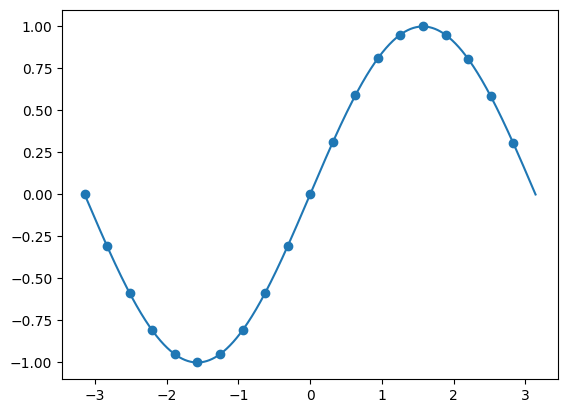

In [8]:
plt.plot(x,y)
plt.scatter(x[::100], y[::100], marker='o')

In [21]:
# random initialize weights
a = np.random.randn()
b = np.random.randn()
c = np.random.randn()
d = np.random.randn()

In [22]:
learning_rate = 1e-6
for t in range(20000):
    # forward pass -> predict y
    # y = a + b x + c x^2 + d x^3
    y_hat = a + b * x + c * x**2 + d * x**3

    # compute loss
    loss = np.square(y_hat - y).sum()
    if t % 100 == 99:
        print(t, loss)
    
    # backprop to compute gradients of a, b, c, d wrt loss
    grad_y_hat = 2.0 * (y_hat - y)
    grad_a = grad_y_hat.sum()
    grad_b = (grad_y_hat * x).sum()
    grad_c = (grad_y_hat * x**2).sum()
    grad_d = (grad_y_hat * x**3).sum()

    # update parameters
    a -= learning_rate * grad_a
    b -= learning_rate * grad_b
    c -= learning_rate * grad_c
    d -= learning_rate * grad_d

print(f'Result: y = {a} + {b} x + {c} x^2 + {d} x^3')

99 1698.549484217769
199 1127.39243578457
299 749.3524381647529
399 499.116964834344
499 333.4672366583218
599 223.80290576325862
699 151.1964742339793
799 103.12115350074225
899 71.28583465021646
999 50.20252377571521
1099 36.23839433444511
1199 26.988486732940355
1299 20.86057332912094
1399 16.800415065809812
1499 14.109920884345852
1599 12.326787794349542
1699 11.144829482696624
1799 10.361234599948036
1899 9.841649548222785
1999 9.49705992858183
2099 9.268482490560839
2199 9.116827889057891
2299 9.016186963143966
2399 8.949383879616633
2499 8.905030406818664
2599 8.875574343534206
2699 8.85600641750746
2799 8.843003364480424
2899 8.834359974693996
2999 8.8286126034372
3099 8.824789559151764
3199 8.822245581764697
3299 8.820552061865161
3399 8.819424214881746
3499 8.818672759946967
3599 8.81817185074258
3699 8.817837787115417
3799 8.817614879642505
3899 8.817466061183913
3999 8.817366649482038
4099 8.817300201953316
4199 8.817255760001832
4299 8.817226016442314
4399 8.81720609636362

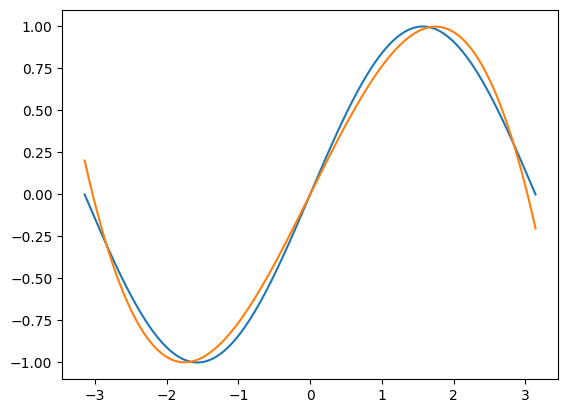

In [23]:
y_hat = a + b * x + c * x**2 + d * x**3
plt.plot(x, y)
plt.plot(x, y_hat)

In [11]:
dtype = torch.float
device = torch.device("cpu")

In [12]:
x = torch.linspace(-math.pi, math.pi, 2000, device=device, dtype=dtype)
y = torch.sin(x)

In [13]:
a = torch.randn((), device=device, dtype=dtype)
b = torch.randn((), device=device, dtype=dtype)
c = torch.randn((), device=device, dtype=dtype)
d = torch.randn((), device=device, dtype=dtype)

In [14]:
learning_rate = 1e-6
for t in range(2000):
    # forward pass
    y_hat = a + b * x + c * x**2 + d * x**3
    loss = (y_hat - y).pow(2).sum().item()
    if t % 100 == 99:
        print(t, loss)

    # backprop
    grad_y_hat = 2.0 * (y_hat - y)
    grad_a = grad_y_hat.sum()
    grad_b = (grad_y_hat * x).sum()
    grad_c = (grad_y_hat * x ** 2).sum()
    grad_d = (grad_y_hat * x ** 3).sum()

    # update weights
    a -= learning_rate * grad_a
    b -= learning_rate * grad_b
    c -= learning_rate * grad_c
    d -= learning_rate * grad_d

print(f'Result: y = {a.item()} + {b.item()} x + {c.item()} x^2 + {d.item()} x^3')

99 585.356201171875
199 392.0967712402344
299 263.7062072753906
399 178.38543701171875
499 121.66838073730469
599 83.9525375366211
699 58.86332702636719
799 42.166725158691406
899 31.05116081237793
999 23.647876739501953
1099 18.71484375
1199 15.426376342773438
1299 13.23304557800293
1399 11.769391059875488
1499 10.792145729064941
1599 10.139253616333008
1699 9.702831268310547
1799 9.410895347595215
1899 9.21549129486084
1999 9.084610939025879
Result: y = 0.00831482745707035 + 0.8706839680671692 x + -0.0014344473602250218 x^2 + -0.0953136682510376 x^3


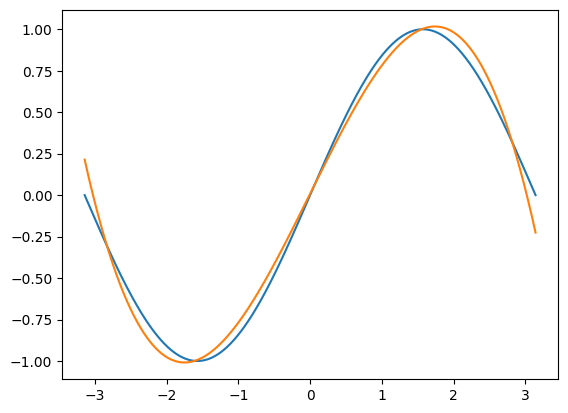

In [15]:
y_hat = a + b * x + c * x**2 + d * x**3
plt.plot(x, y)
plt.plot(x, y_hat)

In [16]:
torch.set_default_device(device)

In [17]:
x = torch.linspace(-math.pi, math.pi, 2000, dtype=dtype)
y = torch.sin(x)

In [18]:
a = torch.randn((), dtype=dtype, requires_grad=True)
b = torch.randn((), dtype=dtype, requires_grad=True)
c = torch.randn((), dtype=dtype, requires_grad=True)
d = torch.randn((), dtype=dtype, requires_grad=True)

In [26]:
learning_rate = 1e-6
for t in range(2000):
    # Forward pass: compute predicted y using operations on Tensors.
    y_hat = a + b * x + c * x ** 2 + d * x ** 3

    # Compute and print loss using operations on Tensors.
    # Now loss is a Tensor of shape (1,)
    # loss.item() gets the scalar value held in the loss.
    loss = (y_hat - y).pow(2).sum()
    if t % 100 == 99:
        print(t, loss.item())

    loss.backward()

    with torch.no_grad():
        a -= learning_rate * a.grad
        b -= learning_rate * b.grad
        c -= learning_rate * c.grad
        d -= learning_rate * d.grad

        # Manually zero the gradients after updating weights
        a.grad = None
        b.grad = None
        c.grad = None
        d.grad = None

print(f'Result: y = {a.item()} + {b.item()} x + {c.item()} x^2 + {d.item()} x^3')

99 8.817171096801758
199 8.817169189453125
299 8.817168235778809
399 8.817168235778809
499 8.817167282104492
599 8.817167282104492
699 8.817168235778809
799 8.817167282104492
899 8.817167282104492
999 8.817167282104492
1099 8.817167282104492
1199 8.817167282104492
1299 8.817167282104492
1399 8.817166328430176
1499 8.817167282104492
1599 8.817167282104492
1699 8.817167282104492
1799 8.817166328430176
1899 8.817167282104492
1999 8.817167282104492
Result: y = -2.325762352484162e-06 + 0.8567265868186951 x + 4.0374638388129824e-07 x^2 + -0.09332836419343948 x^3


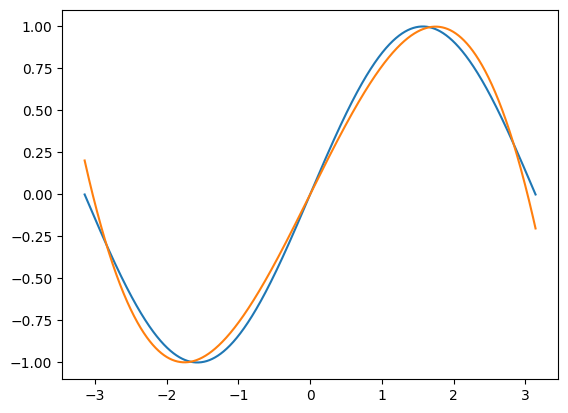

In [27]:
y_hat = a + b * x + c * x**2 + d * x**3
plt.plot(x, y)
plt.plot(x, y_hat.detach())

In [28]:
from typing import Any


class LegendrePolynomial3(torch.autograd.Function):
    @staticmethod
    def forward(ctx, input):
        ctx.save_for_backward(input)
        return 0.5 * (5 * input ** 3 - 3 * input)
    
    @staticmethod
    def backward(ctx: Any, grad_output):
        input, = ctx.saved_tensors
        return grad_output * 1.5 * (5 * input ** 2 - 1)

In [29]:
a = torch.full((), 0.0,  dtype=dtype, requires_grad=True)
b = torch.full((), -1.0,  dtype=dtype, requires_grad=True)
c = torch.full((), 0.0,  dtype=dtype, requires_grad=True)
d = torch.full((), 0.3, dtype=dtype, requires_grad=True)

In [32]:
learning_rate = 5e-6
for t in range(2000):
    P3 = LegendrePolynomial3.apply
    y_hat = a + b * P3(c + d * x)
    loss = (y_hat - y).pow(2).sum()
    if t % 100 == 99:
        print(t, loss.item())

    loss.backward()

    with torch.no_grad():
        a -= learning_rate * a.grad
        b -= learning_rate * b.grad
        c -= learning_rate * c.grad
        d -= learning_rate * d.grad

        # Manually zero the gradients after updating weights
        a.grad = None
        b.grad = None
        c.grad = None
        d.grad = None

print(f'Result: y = {a.item()} + {b.item()} * P3({c.item()} + {d.item()} x)')

99 209.95834350585938
199 144.66018676757812
299 100.70249938964844
399 71.03519439697266
499 50.97850799560547
599 37.403133392333984
699 28.206867218017578
799 21.97318458557129
899 17.7457275390625
999 14.877889633178711
1099 12.93176555633545
1199 11.610918998718262
1299 10.714258193969727
1399 10.105483055114746
1499 9.692106246948242
1599 9.411375999450684
1699 9.220745086669922
1799 9.091285705566406
1899 9.003361701965332
1999 8.943641662597656
Result: y = -5.901059640933681e-10 + -2.208526849746704 * P3(-2.725097647537922e-10 + 0.2554861009120941 x)


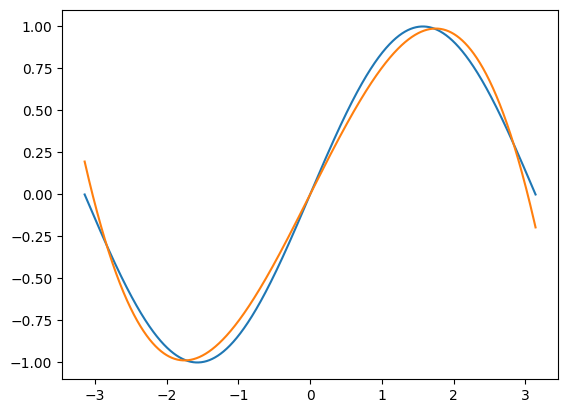

In [34]:
y_hat = a + b * P3(c + d * x)
plt.plot(x, y)
plt.plot(x, y_hat.detach())

In [35]:
# Create Tensors to hold input and outputs.
x = torch.linspace(-math.pi, math.pi, 2000)
y = torch.sin(x)

# For this example, the output y is a linear function of (x, x^2, x^3), so
# we can consider it as a linear layer neural network. Let's prepare the
# tensor (x, x^2, x^3).
p = torch.tensor([1, 2, 3])
xx = x.unsqueeze(-1).pow(p)

In [54]:
model = torch.nn.Sequential(
    torch.nn.Linear(3,1),
    torch.nn.Flatten(0,1)
)

In [65]:
loss_fn = torch.nn.MSELoss(reduction='mean')

In [66]:
learning_rate = 1e-6
for t in range(2000):
    y_hat = model(xx)
    loss = loss_fn(y_hat, y)
    if t % 100 == 99:
        print(t, loss.item())

    model.zero_grad()
    loss.backward()

    with torch.no_grad():
        for param in model.parameters():
            param -= learning_rate * param.grad    

99 0.004436274524778128
199 0.004436273593455553
299 0.004436273127794266
399 0.004436271730810404
499 0.0044362712651491165
599 0.004436270333826542
699 0.00443626893684268
799 0.004436268005520105
899 0.004436267539858818
999 0.004436267074197531
1099 0.004436265677213669
1199 0.0044362652115523815
1299 0.00443626381456852
1399 0.004436262883245945
1499 0.00443626195192337
1599 0.004436261020600796
1699 0.004436260089278221
1799 0.0044362591579556465
1899 0.004436258226633072
1999 0.004436257295310497


In [67]:
# Create Tensors to hold input and outputs.
x = torch.linspace(-math.pi, math.pi, 2000)
y = torch.sin(x)

# Prepare the input tensor (x, x^2, x^3).
p = torch.tensor([1, 2, 3])
xx = x.unsqueeze(-1).pow(p)

# Use the nn package to define our model and loss function.
model = torch.nn.Sequential(
    torch.nn.Linear(3, 1),
    torch.nn.Flatten(0, 1)
)
loss_fn = torch.nn.MSELoss(reduction='sum')

In [75]:
learning_rate = 1e-3
optimizer = torch.optim.RMSprop(model.parameters())
for t in range(2000):
    y_hat = model(xx)

    loss = loss_fn(y_hat, y)
    if t % 100 == 99:
        print(t, loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()   

99 257.1617736816406
199 35.6177864074707
299 9.56420612335205
399 9.59780502319336
499 9.630853652954102
599 9.658413887023926
699 34.67940139770508
799 25.35306739807129
899 16.367273330688477
999 15.623333930969238
1099 19.18406867980957
1199 20.770919799804688
1299 19.018325805664062
1399 18.63870620727539
1499 19.248464584350586
1599 19.374996185302734
1699 19.138879776000977
1799 19.107149124145508
1899 19.194326400756836
1999 19.201702117919922


In [78]:
model[0].bias

Parameter containing:
tensor([-0.0050], requires_grad=True)

In [58]:
a

{'a': 2, 'b': 3, 'c': 4}